In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier

In [4]:
!pip install xgboost

In [5]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import pickle

In [6]:
df = pd.read_csv('C:/Users/Saurabh/Downloads/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [7]:
df.shape

(7043, 21)

In [8]:
df.sample(3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2467,6559-RAKOZ,Male,0,Yes,Yes,49,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,One year,Yes,Electronic check,97.95,4917.9,No
3102,0516-WJVXC,Female,0,No,No,5,Yes,No,DSL,Yes,...,No,Yes,No,No,Month-to-month,No,Electronic check,54.20,308.25,Yes
1620,6022-KOUQO,Female,0,Yes,Yes,2,No,No phone service,DSL,No,...,No,Yes,No,No,Month-to-month,No,Bank transfer (automatic),29.05,44.75,No


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
numerical_features_list = ['MonthlyCharges','TotalCharges','tenure']

for col in df.columns:
    if col not in numerical_features_list:
        print(col, df[col].unique())
        print('-'*50)

customerID ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
--------------------------------------------------
gender ['Female' 'Male']
--------------------------------------------------
SeniorCitizen [0 1]
--------------------------------------------------
Partner ['Yes' 'No']
--------------------------------------------------
Dependents ['No' 'Yes']
--------------------------------------------------
PhoneService ['No' 'Yes']
--------------------------------------------------
MultipleLines ['No phone service' 'No' 'Yes']
--------------------------------------------------
InternetService ['DSL' 'Fiber optic' 'No']
--------------------------------------------------
OnlineSecurity ['No' 'Yes' 'No internet service']
--------------------------------------------------
OnlineBackup ['Yes' 'No' 'No internet service']
--------------------------------------------------
DeviceProtection ['No' 'Yes' 'No internet service']
---------------------------------------

In [11]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [12]:
df[df['TotalCharges']==' ']

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [13]:
len(df[df['TotalCharges']==' '])

11

In [14]:
df['TotalCharges'] = df['TotalCharges'].replace({' ':'0.0'})

In [15]:
df['TotalCharges'] = df['TotalCharges'].astype(float)

In [16]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [17]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [18]:
((df['Churn'].value_counts()) / df.shape[0])*100

Churn
No     73.463013
Yes    26.536987
Name: count, dtype: float64

In [19]:
df[df.duplicated()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

In [22]:
df = df.drop(columns=['customerID'])

In [23]:
def plot_histogram(df, column_name):

  plt.figure(figsize=(5, 3))
  sns.histplot(df[column_name], kde=True)
  plt.title(f"Distribution of {column_name}")

  col_mean = df[column_name].mean()
  col_median = df[column_name].median()

  plt.axvline(col_mean, color="red", linestyle="--", label="Mean")
  plt.axvline(col_median, color="green", linestyle="-", label="Median")

  plt.legend()

  plt.show()

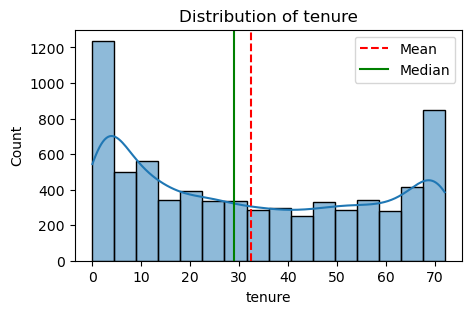

In [24]:
plot_histogram(df, "tenure")

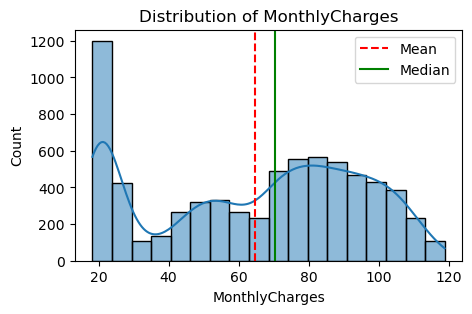

In [25]:
plot_histogram(df, "MonthlyCharges")

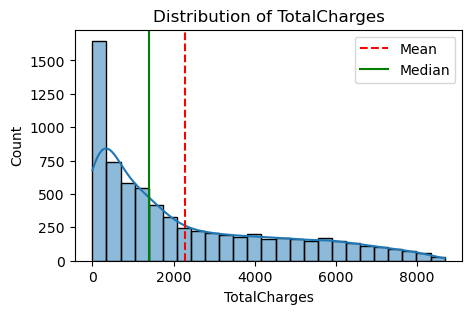

In [26]:
plot_histogram(df, "TotalCharges")

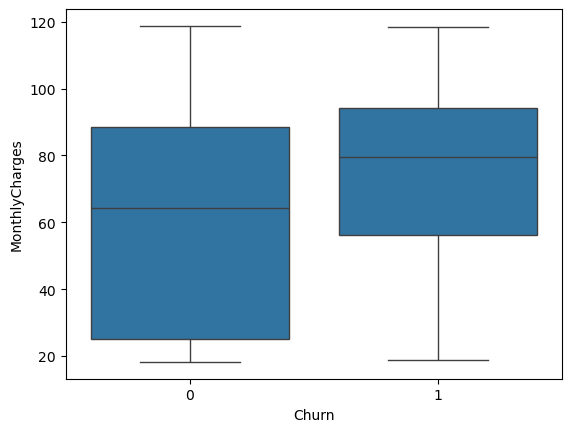

In [27]:
sns.boxplot(x='Churn',y='MonthlyCharges', data=df)
plt.show()

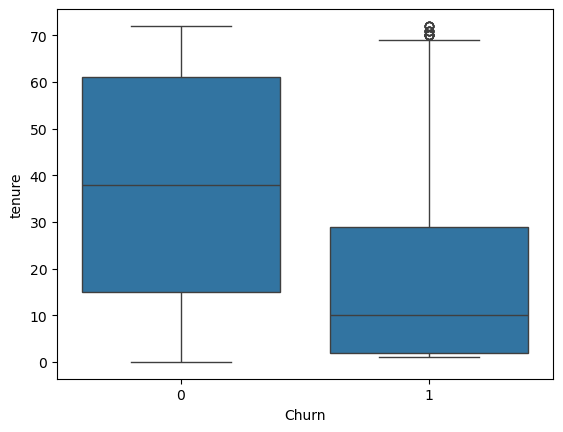

In [28]:
sns.boxplot(x='Churn',y='tenure', data=df)
plt.show()

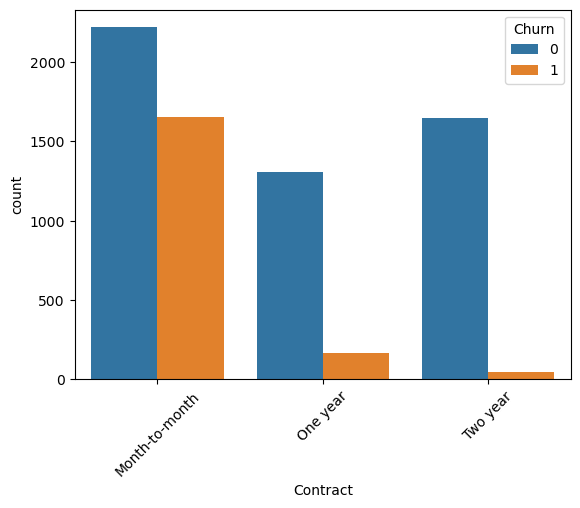

In [29]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.show()

In [30]:
pd.crosstab(df['InternetService'], df['Churn'])

Churn,0,1
InternetService,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


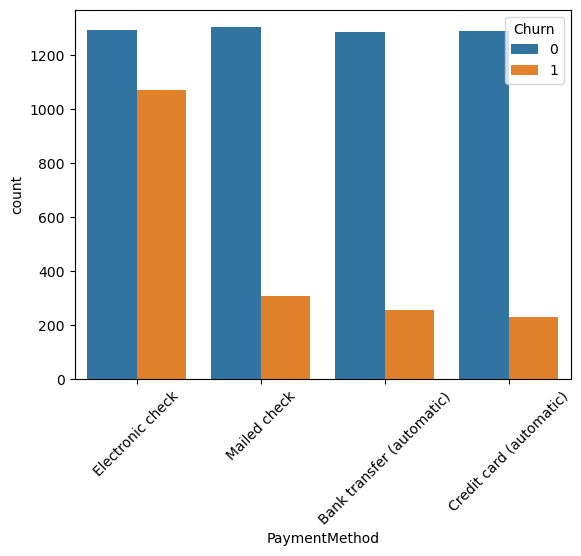

In [31]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.show()

In [32]:
df['Partner'] = df['Partner'].map({'Yes':1, 'No':0})

In [33]:
df['Partner'].unique()

array([1, 0])

In [34]:
df['Dependents'] = df['Dependents'].map({'Yes':1, 'No':0})

In [35]:
df['Dependents'].unique()

array([0, 1])

In [36]:
df['PhoneService'] = df['PhoneService'].map({'Yes':1, 'No':0})

In [37]:
df['MultipleLines'].unique()

array(['No phone service', 'No', 'Yes'], dtype=object)

In [38]:
df['MultipleLines'] = df['MultipleLines'].map({'Yes':1, 'No':0, 'No phone service':0})

In [39]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [40]:
x_train, x_test, y_train, y_test = train_test_split(X,y,test_size=0.3)

In [41]:
from sklearn.compose import ColumnTransformer

In [42]:
from sklearn.preprocessing import OneHotEncoder

transformer = ColumnTransformer(
    transformers=[
        ('tnf1', OneHotEncoder(sparse_output=False, drop='first'), ['gender','PaymentMethod','InternetService','Contract'])
    ],
    remainder='passthrough'
)

In [43]:
X_train_transformed = transformer.fit_transform(x_train)

In [44]:
X_test_transformed = transformer.transform(x_test)

In [57]:
categorical_cols = x_train.select_dtypes(include='object').columns

transformer = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ],
    remainder='passthrough'
)

X_train_transformed = transformer.fit_transform(x_train)
X_test_transformed = transformer.transform(x_test)

In [58]:
x_train.sample(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
1736,Female,0,0,0,-1.259508,1,0,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,-1.513654,-0.989876
141,Female,0,0,0,-0.974832,1,1,DSL,Yes,No,No,Yes,No,Yes,Month-to-month,No,Electronic check,0.214989,-0.748056
5296,Female,0,0,0,1.017893,0,0,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Credit card (automatic),-0.790737,0.005021


In [59]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [60]:
from sklearn.preprocessing import StandardScaler

In [61]:
ss = StandardScaler()

In [62]:
num_cols = ['MonthlyCharges','TotalCharges','tenure']

In [63]:
x_train[num_cols] = ss.fit_transform(x_train[num_cols])

In [64]:
x_test[num_cols] = ss.fit_transform(x_test[num_cols])

In [65]:
from sklearn.linear_model import LogisticRegression

In [119]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced')

In [120]:
lr.fit(X_train_transformed, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [121]:
y_pred = lr.predict(X_test_transformed)

In [122]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, f1_score , precision_score, recall_score

In [123]:
accuracy_score(y_test,y_pred)

0.7401798390913393

In [124]:
confusion_matrix(y_test, y_pred)

array([[1142,  425],
       [ 124,  422]])

In [125]:
precision_score(y_test, y_pred)

0.4982290436835891

In [126]:
297 / (297 + 165)

0.6428571428571429

In [127]:
recall_score(y_test, y_pred)

0.7728937728937729

In [128]:
297 / (297 + 249)

0.5439560439560439

In [129]:
f1_score(y_test, y_pred)

0.6058865757358219

In [130]:
classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n           0       0.90      0.73      0.81      1567\n           1       0.50      0.77      0.61       546\n\n    accuracy                           0.74      2113\n   macro avg       0.70      0.75      0.71      2113\nweighted avg       0.80      0.74      0.75      2113\n'

In [84]:
from sklearn.ensemble import RandomForestClassifier

In [132]:
rfc = RandomForestClassifier(n_estimators=100, max_depth=10,
    min_samples_split=5, class_weight='balanced',
    min_samples_leaf=2, random_state=42)

In [133]:
rfc.fit(X_train_transformed, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=2, min_samples_split=5,
                       random_state=42)

In [134]:
y_pred_rf = rfc.predict(X_test_transformed)

In [135]:
accuracy_score(y_test,y_pred_rf)

0.7695220066256507

In [136]:
confusion_matrix(y_test, y_pred_rf)

array([[1248,  319],
       [ 168,  378]])

In [137]:
recall_score(y_test, y_pred_rf)

0.6923076923076923

In [138]:
precision_score(y_test, y_pred_rf)

0.5423242467718795

In [139]:
f1_score(y_test, y_pred_rf)

0.6082059533386966

In [140]:
from xgboost import XGBClassifier

In [141]:
scale_pos_weight = (len(y_train[y_train==0]) / len(y_train[y_train==1]))
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5, scale_pos_weight=scale_pos_weight,
    random_state=42
)

In [150]:
y_prob = xgb.predict_proba(X_test_transformed)[:,1]

y_pred_xgb = (y_prob > 0.4).astype(int)  # instead of 0.5

In [151]:
xgb.fit(X_train_transformed, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [152]:
y_pred_xgb = xgb.predict(X_test_transformed)

In [153]:
accuracy_score(y_test,y_pred_xgb)

0.754850922858495

In [154]:
confusion_matrix(y_test, y_pred_xgb)

array([[1190,  377],
       [ 141,  405]])

In [155]:
precision_score(y_test, y_pred_xgb)

0.5179028132992327

In [156]:
recall_score(y_test, y_pred_xgb)

0.7417582417582418

In [157]:
f1_score(y_test, y_pred_xgb)

0.6099397590361446

In [158]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Logistic Regression
lr_acc = accuracy_score(y_test, y_pred)
lr_prec = precision_score(y_test, y_pred)
lr_rec = recall_score(y_test, y_pred)
lr_f1 = f1_score(y_test, y_pred)

# Random Forest
rf_acc = accuracy_score(y_test, y_pred_rf)
rf_prec = precision_score(y_test, y_pred_rf)
rf_rec = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

# XGBoost
xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_prec = precision_score(y_test, y_pred_xgb)
xgb_rec = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)

# Create DataFrame
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [lr_acc, rf_acc, xgb_acc],
    'Precision': [lr_prec, rf_prec, xgb_prec],
    'Recall': [lr_rec, rf_rec, xgb_rec],
    'F1 Score': [lr_f1, rf_f1, xgb_f1]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.740180   0.498229  0.772894  0.605887
1        Random Forest  0.769522   0.542324  0.692308  0.608206
2              XGBoost  0.754851   0.517903  0.741758  0.609940


In [159]:
import pickle

pickle.dump(xgb, open('model.pkl', 'wb'))
pickle.dump(transformer, open('transformer.pkl', 'wb'))